## Dataset Analysis

In [ ]:
!pip uninstall -y transformers tokenizers
!pip install transformers==4.36.2 tokenizers==0.15.0 sentencepiece

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, b

### Counting Dataset

In [ ]:
import json
import numpy as np
from collections import Counter
from transformers import AutoTokenizer
from transformers import RobertaTokenizer
from transformers import T5Tokenizer
from google.colab import drive
drive.mount('/content/drive')


DATASET_PATH = "/content/drive/MyDrive/vt/NLP_final/binary_dataset.jsonl"
MODEL_NAME = "Salesforce/codet5-small"

# FIX: force slow tokenizer to avoid error
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
# tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

input_token_lens = []
target_token_lens = []
instructions = []

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)

        source = (
            f"Instruction: {item['instruction']}\n"
            f"Input sequence: {item['input']}\n"
            f"Generate Python code."
        )

        target = item["target_code"]

        input_len = len(tokenizer(source)["input_ids"])
        target_len = len(tokenizer(target)["input_ids"])

        input_token_lens.append(input_len)
        target_token_lens.append(target_len)

        instructions.append(item["instruction"])

input_token_lens = np.array(input_token_lens)
target_token_lens = np.array(target_token_lens)

# =========================
# Input stats
# =========================
print("\n========== Input Token Length ==========")
print(f"Min: {input_token_lens.min()}")
print(f"Max: {input_token_lens.max()}")
print(f"Mean: {input_token_lens.mean():.2f}")

# =========================
# Target stats
# =========================
print("\n========== Target Token Length ==========")
print(f"Min: {target_token_lens.min()}")
print(f"Max: {target_token_lens.max()}")
print(f"Mean: {target_token_lens.mean():.2f}")

# =========================
# Instruction diversity
# =========================
instruction_counter = Counter(instructions)

print("\n========== Instruction Diversity ==========")
print(f"Unique instructions: {len(instruction_counter)}")

print("\nTop 5 instructions:")
for inst, cnt in instruction_counter.most_common(5):
    print(f"{cnt} - {inst}")

# =========================
# Recommendation (100% coverage)
# =========================
print("\n========== Recommended Settings ==========")

max_input = int(input_token_lens.max())
max_target = int(target_token_lens.max())

# add small buffer
MAX_INPUT_LEN = max_input + 20
MAX_TARGET_LEN = max_target + 10

print(f"MAX_INPUT_LEN = {MAX_INPUT_LEN}")
print(f"MAX_TARGET_LEN = {MAX_TARGET_LEN}")

print("\nNotes:")
print("- Covers 100% of dataset (no truncation)")
print("- Small buffer added for safety")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

========== Input Token Length ==========
Min: 31
Max: 75
Mean: 56.47

========== Target Token Length ==========
Min: 22
Max: 22
Mean: 22.00

========== Instruction Diversity ==========
Unique instructions: 17

Top 5 instructions:
82 - Please compute the number of 0s and 1s
71 - From the sequence below, find the counts of 0 and 1
69 - Find the count of 0 and 1
68 - What is the total number of 0s and 1s?
63 - How many 0s and 1s are there?

========== Recommended Settings ==========
MAX_INPUT_LEN = 95
MAX_TARGET_LEN = 32

Notes:
- Covers 100% of dataset (no truncation)
- Small buffer added for safety


### Mixed Dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

========== Dataset Summary ==========
Total samples: 3000

Task counts:
binary_count: 1000
longest_substring: 1000
arithmetic: 1000

========== Overall Input Token Length ==========
Min: 31
Max: 140
Mean: 78.71
Median: 76.00
95th percentile: 108.00
99th percentile: 119.00

========== Overall Target Token Length ==========
Min: 16
Max: 73
Mean: 40.22
Median: 32.00
95th percentile: 73.00
99th percentile: 73.00

========== Token Length by Task ==========

--- arithmetic ---
Samples: 1000
Input:
  Min: 60
  Max: 107
  Mean: 79.37
  95th percentile: 101.00
Target:
  Min: 16
  Max: 16
  Mean: 16.00
  95th percentile: 16.00

--- binary_count ---
Samples: 1000
Input:
  Min: 37
  Max: 81
  Mean: 62.47
  95th percentile: 75.00
Target:
  Min: 32
  Max: 32
  Mean: 32.00
  95th percentile: 32.00

--- longest_substring ---
Samples: 1000
Input:
  Min: 31
  Max: 140
  Mean:

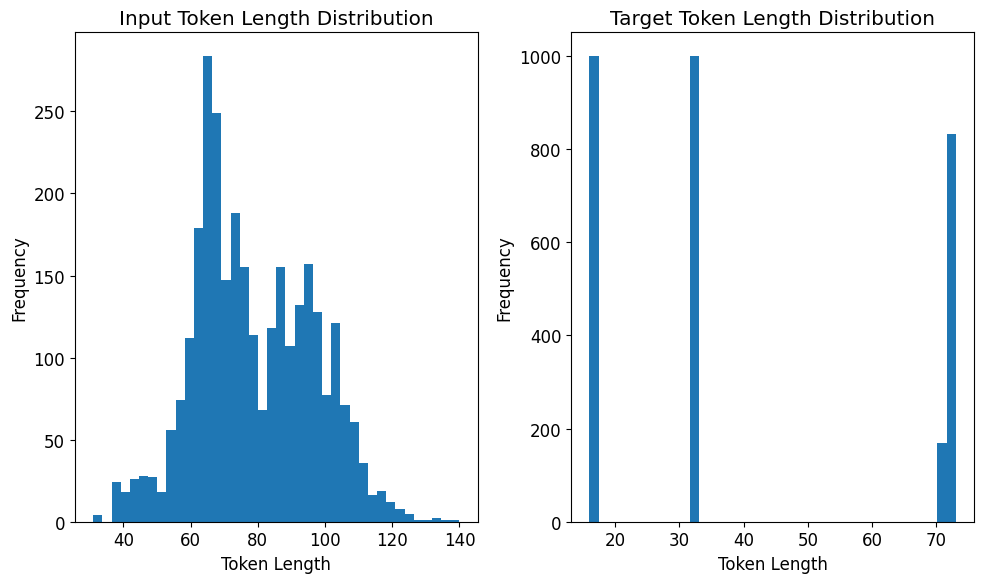


Figure saved to: /content/drive/MyDrive/vt/NLP_final/data_analysis2.png


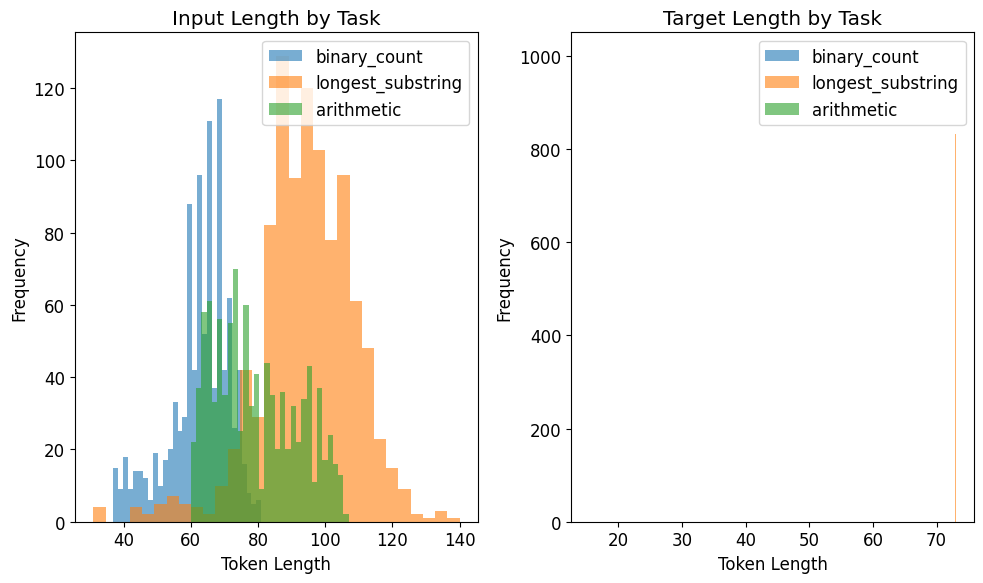

In [ ]:
import json
import numpy as np
from collections import Counter, defaultdict
from transformers import AutoTokenizer
from google.colab import drive
drive.mount('/content/drive')



DATASET_PATHS = [
    "/content/drive/MyDrive/vt/NLP_final/binary_dataset.jsonl",
    "/content/drive/MyDrive/vt/NLP_final/substring_dataset.jsonl",
    "/content/drive/MyDrive/vt/NLP_final/arithmetic_dataset.jsonl",
]

MODEL_NAME = "Salesforce/codet5-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

input_token_lens = []
target_token_lens = []
instructions = []
task_types = []

input_lens_by_task = defaultdict(list)
target_lens_by_task = defaultdict(list)


def build_source(item):
    return (
        f"Task type: {item['task_type']}\n"
        f"Instruction: {item['instruction']}\n"
        f"Input: {item['input']}\n"
        f"Generate Python code."
    )


for path in DATASET_PATHS:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)

            source = build_source(item)
            target = item["target_code"].strip()

            input_len = len(tokenizer(source)["input_ids"])
            target_len = len(tokenizer(target)["input_ids"])

            input_token_lens.append(input_len)
            target_token_lens.append(target_len)

            instructions.append(item["instruction"])
            task_types.append(item["task_type"])

            input_lens_by_task[item["task_type"]].append(input_len)
            target_lens_by_task[item["task_type"]].append(target_len)


input_token_lens = np.array(input_token_lens)
target_token_lens = np.array(target_token_lens)

print("\n========== Dataset Summary ==========")
print(f"Total samples: {len(input_token_lens)}")

task_counter = Counter(task_types)
print("\nTask counts:")
for task, cnt in task_counter.items():
    print(f"{task}: {cnt}")


print("\n========== Overall Input Token Length ==========")
print(f"Min: {input_token_lens.min()}")
print(f"Max: {input_token_lens.max()}")
print(f"Mean: {input_token_lens.mean():.2f}")
print(f"Median: {np.median(input_token_lens):.2f}")
print(f"95th percentile: {np.percentile(input_token_lens, 95):.2f}")
print(f"99th percentile: {np.percentile(input_token_lens, 99):.2f}")


print("\n========== Overall Target Token Length ==========")
print(f"Min: {target_token_lens.min()}")
print(f"Max: {target_token_lens.max()}")
print(f"Mean: {target_token_lens.mean():.2f}")
print(f"Median: {np.median(target_token_lens):.2f}")
print(f"95th percentile: {np.percentile(target_token_lens, 95):.2f}")
print(f"99th percentile: {np.percentile(target_token_lens, 99):.2f}")


print("\n========== Token Length by Task ==========")

for task in sorted(task_counter.keys()):
    input_arr = np.array(input_lens_by_task[task])
    target_arr = np.array(target_lens_by_task[task])

    print(f"\n--- {task} ---")
    print(f"Samples: {len(input_arr)}")

    print("Input:")
    print(f"  Min: {input_arr.min()}")
    print(f"  Max: {input_arr.max()}")
    print(f"  Mean: {input_arr.mean():.2f}")
    print(f"  95th percentile: {np.percentile(input_arr, 95):.2f}")

    print("Target:")
    print(f"  Min: {target_arr.min()}")
    print(f"  Max: {target_arr.max()}")
    print(f"  Mean: {target_arr.mean():.2f}")
    print(f"  95th percentile: {np.percentile(target_arr, 95):.2f}")


print("\n========== Instruction Diversity ==========")

instruction_counter = Counter(instructions)
print(f"Unique instructions: {len(instruction_counter)}")

print("\nTop 10 instructions:")
for inst, cnt in instruction_counter.most_common(10):
    print(f"{cnt} - {inst}")


print("\n========== Instruction Diversity by Task ==========")

for task in sorted(task_counter.keys()):
    task_insts = [
        inst for inst, t in zip(instructions, task_types)
        if t == task
    ]
    task_inst_counter = Counter(task_insts)

    print(f"\n--- {task} ---")
    print(f"Unique instructions: {len(task_inst_counter)}")
    print("Top 5:")
    for inst, cnt in task_inst_counter.most_common(5):
        print(f"  {cnt} - {inst}")


print("\n========== Recommended Settings ==========")

max_input = int(input_token_lens.max())
max_target = int(target_token_lens.max())

MAX_INPUT_LEN = max_input + 20
MAX_TARGET_LEN = max_target + 10

print(f"MAX_INPUT_LEN = {MAX_INPUT_LEN}")
print(f"MAX_TARGET_LEN = {MAX_TARGET_LEN}")

print("\nNotes:")
print("- Covers 100% of mixed dataset, no truncation.")
print("- Buffer added: +20 for input, +10 for target.")
print("- Use these values in your CodeT5 mixed training script.")






# data_analysis plot
import matplotlib.pyplot as plt

# =========================
# Plotting (for paper figure)
# =========================

# Use clean academic style
plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (10, 6),
})

fig, axes = plt.subplots(1, 2)

# ---- Left: Input token length distribution ----
axes[0].hist(input_token_lens, bins=40)
axes[0].set_title("Input Token Length Distribution")
axes[0].set_xlabel("Token Length")
axes[0].set_ylabel("Frequency")

# ---- Right: Target token length distribution ----
axes[1].hist(target_token_lens, bins=40)
axes[1].set_title("Target Token Length Distribution")
axes[1].set_xlabel("Token Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

# Save figure
save_path = "/content/drive/MyDrive/vt/NLP_final/data_analysis1.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"\nFigure saved to: {save_path}")
plt.show()


# =========================
# Advanced plot (per-task comparison)
# =========================

fig, axes = plt.subplots(1, 2)

# Input lengths by task
for task, arr in input_lens_by_task.items():
    axes[0].hist(arr, bins=30, alpha=0.6, label=task)

axes[0].set_title("Input Length by Task")
axes[0].set_xlabel("Token Length")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Target lengths by task
for task, arr in target_lens_by_task.items():
    axes[1].hist(arr, bins=30, alpha=0.6, label=task)

axes[1].set_title("Target Length by Task")
axes[1].set_xlabel("Token Length")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()

save_path = "/content/drive/MyDrive/vt/NLP_final/data_analysis2.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"\nFigure saved to: {save_path}")
plt.show()

## CodeT5-small

In [ ]:
!pip uninstall -y transformers tokenizers peft accelerate
!pip install transformers==4.36.2 tokenizers==0.15.0 accelerate==0.25.0 sentencepiece

Found existing installation: transformers 4.36.2
Uninstalling transformers-4.36.2:
  Successfully uninstalled transformers-4.36.2
Found existing installation: tokenizers 0.15.0
Uninstalling tokenizers-0.15.0:
  Successfully uninstalled tokenizers-0.15.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
  Using cached tokenizers-0.15.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.36.2-py3-none-any.whl (8.2 MB)
Using cached tokenizers-0.15.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are i

### Single Training: Counting Problem

In [ ]:
import json
import random
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
from google.colab import drive
drive.mount("/content/drive")


MODEL_NAME = "Salesforce/codet5-small"
DATASET_PATH = "/content/drive/MyDrive/vt/NLP_final/binary_dataset.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/vt/NLP_final/codet5_binary_counter"

SEED = 42
TRAIN_RATIO = 0.9

MAX_INPUT_LEN = 96
MAX_TARGET_LEN = 32


def load_data(path):
    data = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)

            source = (
                f"Instruction: {item['instruction']}\n"
                f"Input sequence: {item['input']}\n"
                f"Generate Python code."
            )

            target = item["target_code"]

            data.append({
                "source": source,
                "target": target,
            })

    return data


def main():
    random.seed(SEED)
    torch.manual_seed(SEED)

    data = load_data(DATASET_PATH)
    random.shuffle(data)

    split_idx = int(len(data) * TRAIN_RATIO)
    train_data = data[:split_idx]
    val_data = data[split_idx:]

    print(f"Train samples: {len(train_data)}")
    print(f"Val samples: {len(val_data)}")

    train_dataset = Dataset.from_list(train_data)
    val_dataset = Dataset.from_list(val_data)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

    def preprocess(batch):
        model_inputs = tokenizer(
            batch["source"],
            max_length=MAX_INPUT_LEN,
            truncation=True,
        )

        labels = tokenizer(
            text_target=batch["target"],
            max_length=MAX_TARGET_LEN,
            truncation=True,
        )

        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    train_dataset = train_dataset.map(
        preprocess,
        batched=True,
        remove_columns=train_dataset.column_names,
    )

    val_dataset = val_dataset.map(
        preprocess,
        batched=True,
        remove_columns=val_dataset.column_names,
    )

    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir=OUTPUT_DIR,

        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=20,

        learning_rate=5e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=6,
        weight_decay=0.01,

        predict_with_generate=True,
        generation_max_length=MAX_TARGET_LEN,

        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
    )

    trainer.train()

    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)

    print("Training finished. Model saved to:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train samples: 900
Val samples: 100


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss
1,0.000500,0.000028
2,0.000100,0.000012
3,0.000100,0.000008
4,0.000100,0.000006
5,0.000100,0.000005
6,0.000100,0.000005


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

Training finished. Model saved to: /content/drive/MyDrive/vt/NLP_final/codet5_binary_counter


### Single Testing Counting Problem

In [ ]:
import json
import random
import re
import io
import contextlib
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from google.colab import drive
drive.mount("/content/drive")


MODEL_PATH = "/content/drive/MyDrive/vt/NLP_final/codet5_binary_counter"
DATASET_PATH = "/content/drive/MyDrive/vt/NLP_final/binary_dataset.jsonl"

SEED = 42
TEST_RATIO = 0.1

MAX_INPUT_LEN = 96
MAX_TARGET_LEN = 32


def load_data(path):
    data = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)

            source = (
                f"Instruction: {item['instruction']}\n"
                f"Input sequence: {item['input']}\n"
                f"Generate Python code."
            )

            data.append({
                "source": source,
                "input": item["input"],
                "count_0": item["output"]["count_0"],
                "count_1": item["output"]["count_1"],
            })

    return data


def execute_code(code, input_data):
    stdout = io.StringIO()

    local_vars = {
        "input_data": input_data
    }

    try:
        with contextlib.redirect_stdout(stdout):
            exec(code, {}, local_vars)

        return True, stdout.getvalue().strip()

    except Exception as e:
        return False, str(e)


def parse_output(output_text):
    nums = re.findall(r"\d+", output_text)

    if len(nums) >= 2:
        return int(nums[0]), int(nums[1])

    return None, None


def main():
    random.seed(SEED)

    data = load_data(DATASET_PATH)
    random.shuffle(data)

    test_size = int(len(data) * TEST_RATIO)
    test_data = data[-test_size:]

    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    correct = 0
    runtime_errors = 0
    format_errors = 0

    for i, sample in enumerate(test_data):
        inputs = tokenizer(
            sample["source"],
            return_tensors="pt",
            max_length=MAX_INPUT_LEN,
            truncation=True,
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                early_stopping=True,
            )

        generated_code = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True,
        )

        success, exec_output = execute_code(
            generated_code,
            sample["input"],
        )

        if not success:
            runtime_errors += 1
            pred_0, pred_1 = None, None
            is_correct = False
        else:
            pred_0, pred_1 = parse_output(exec_output)

            if pred_0 is None or pred_1 is None:
                format_errors += 1
                is_correct = False
            else:
                is_correct = (
                    pred_0 == sample["count_0"]
                    and pred_1 == sample["count_1"]
                )

        if is_correct:
            correct += 1

        print("=" * 60)
        print(f"Sample {i + 1}/{len(test_data)}")
        print("Gold:", sample["count_0"], sample["count_1"])
        print("Generated code:")
        print(generated_code)
        print("Execution output:", exec_output)
        print("Pred:", pred_0, pred_1)
        print("Correct:", is_correct)

    accuracy = correct / len(test_data)

    print("\n========== Final Test Result ==========")
    print(f"Test samples: {len(test_data)}")
    print(f"Correct: {correct}/{len(test_data)}")
    print(f"Execution accuracy: {accuracy:.4f}")
    print(f"Runtime errors: {runtime_errors}")
    print(f"Format errors: {format_errors}")


if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sample 1/100
Gold: 46 67
Generated code:
seq = input_data
print(seq.count('0'), seq.count('1'))
Execution output: 46 67
Pred: 46 67
Correct: True
Sample 2/100
Gold: 49 48
Generated code:
seq = input_data
print(seq.count('0'), seq.count('1'))
Execution output: 49 48
Pred: 49 48
Correct: True
Sample 3/100
Gold: 45 50
Generated code:
seq = input_data
print(seq.count('0'), seq.count('1'))
Execution output: 45 50
Pred: 45 50
Correct: True
Sample 4/100
Gold: 55 45
Generated code:
seq = input_data
print(seq.count('0'), seq.count('1'))
Execution output: 55 45
Pred: 55 45
Correct: True
Sample 5/100
Gold: 0 101
Generated code:
seq = input_data
print(seq.count('0'), seq.count('1'))
Execution output: 0 101
Pred: 0 101
Correct: True
Sample 6/100
Gold: 58 57
Generated code:
seq = input_data
print(seq.count('0'), seq.count('1'))
Execution output: 58 57
Pred: 58 57
Correct: 

## Generalization

### Mixed Training: Counting + Substring + Arithmetic

In [ ]:
import json
import random
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
from google.colab import drive
drive.mount("/content/drive")


MODEL_NAME = "Salesforce/codet5-small"

DATASET_PATHS = [
    "/content/drive/MyDrive/vt/NLP_final/binary_dataset.jsonl",
    "/content/drive/MyDrive/vt/NLP_final/substring_dataset.jsonl",
    "/content/drive/MyDrive/vt/NLP_final/arithmetic_dataset.jsonl",
]

OUTPUT_DIR = "/content/drive/MyDrive/vt/NLP_final/codet5_mixed_computation"

SEED = 42
TRAIN_RATIO = 0.9

MAX_INPUT_LEN = 160
MAX_TARGET_LEN = 83


def load_data(paths):
    data = []

    for path in paths:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                item = json.loads(line)

                source = (
                    f"Task type: {item['task_type']}\n"
                    f"Instruction: {item['instruction']}\n"
                    f"Input: {item['input']}\n"
                    f"Generate Python code."
                )

                target = item["target_code"]

                data.append({
                    "source": source,
                    "target": target,
                })

    return data


def main():
    random.seed(SEED)
    torch.manual_seed(SEED)

    data = load_data(DATASET_PATHS)
    random.shuffle(data)

    split_idx = int(len(data) * TRAIN_RATIO)
    train_data = data[:split_idx]
    val_data = data[split_idx:]

    print(f"Total samples: {len(data)}")
    print(f"Train samples: {len(train_data)}")
    print(f"Val samples: {len(val_data)}")

    train_dataset = Dataset.from_list(train_data)
    val_dataset = Dataset.from_list(val_data)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

    def preprocess(batch):
        model_inputs = tokenizer(
            batch["source"],
            max_length=MAX_INPUT_LEN,
            truncation=True,
        )

        labels = tokenizer(
            text_target=batch["target"],
            max_length=MAX_TARGET_LEN,
            truncation=True,
        )

        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    train_dataset = train_dataset.map(
        preprocess,
        batched=True,
        remove_columns=train_dataset.column_names,
    )

    val_dataset = val_dataset.map(
        preprocess,
        batched=True,
        remove_columns=val_dataset.column_names,
    )

    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir=OUTPUT_DIR,

        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=20,

        learning_rate=5e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=6,
        weight_decay=0.01,

        predict_with_generate=True,
        generation_max_length=MAX_TARGET_LEN,

        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
    )

    trainer.train()

    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)

    print("Training finished. Model saved to:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Mounted at /content/drive
Total samples: 3000
Train samples: 2700
Val samples: 300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:439: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss
1,0.000900,0.000044
2,0.000800,0.000019
3,0.000400,0.000014
4,0.000200,0.000008
5,0.000100,0.000007
6,0.000100,0.000006


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training finished. Model saved to: /content/drive/MyDrive/vt/NLP_final/codet5_mixed_computation


### Mixed Testing Problem

In [ ]:
import json
import random
import re
import io
import contextlib
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from google.colab import drive

drive.mount("/content/drive")


MODEL_PATH = "/content/drive/MyDrive/vt/NLP_final/codet5_mixed_computation"

DATASET_PATHS = [
    "/content/drive/MyDrive/vt/NLP_final/testset/binary_dataset.jsonl",
    "/content/drive/MyDrive/vt/NLP_final/testset/substring_dataset.jsonl",
    "/content/drive/MyDrive/vt/NLP_final/testset/arithmetic_dataset.jsonl",
]

SEED = 42
TEST_RATIO = 0.1

MAX_INPUT_LEN = 160
MAX_TARGET_LEN = 83


def load_data(paths):
    data = []

    for path in paths:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                item = json.loads(line)

                source = (
                    f"Task type: {item['task_type']}\n"
                    f"Instruction: {item['instruction']}\n"
                    f"Input: {item['input']}\n"
                    f"Generate Python code."
                )

                data.append({
                    "source": source,
                    "input": item["input"],
                    "task_type": item["task_type"],
                    "answer": item["output"]["answer"],
                    "output": item["output"],
                })

    return data


def execute_code(code, input_data):
    stdout = io.StringIO()

    local_vars = {
        "input_data": input_data
    }

    try:
        with contextlib.redirect_stdout(stdout):
            exec(code, {}, local_vars)

        return True, stdout.getvalue().strip()

    except Exception as e:
        return False, str(e)


def parse_binary_output(output_text):
    match = re.search(r"0\s*:\s*(\d+)\s*\|\s*1\s*:\s*(\d+)", output_text)
    if match:
        return f"0:{int(match.group(1))} | 1:{int(match.group(2))}"

    nums = re.findall(r"\d+", output_text)
    if len(nums) >= 2:
        return f"0:{int(nums[0])} | 1:{int(nums[1])}"

    return None


def parse_integer_output(output_text):
    nums = re.findall(r"-?\d+", output_text)
    if nums:
        return str(int(nums[-1]))
    return None


def parse_output_by_task(output_text, task_type):
    if task_type == "binary_count":
        return parse_binary_output(output_text)
    elif task_type in ["longest_substring", "arithmetic"]:
        return parse_integer_output(output_text)
    else:
        return None


def main():
    random.seed(SEED)

    data = load_data(DATASET_PATHS)
    random.shuffle(data)

    test_size = int(len(data) * TEST_RATIO)
    test_data = data[-test_size:]

    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    correct = 0
    runtime_errors = 0
    format_errors = 0

    task_stats = {}

    for i, sample in enumerate(test_data):
        task_type = sample["task_type"]

        if task_type not in task_stats:
            task_stats[task_type] = {
                "total": 0,
                "correct": 0,
                "runtime_errors": 0,
                "format_errors": 0,
            }

        task_stats[task_type]["total"] += 1

        inputs = tokenizer(
            sample["source"],
            return_tensors="pt",
            max_length=MAX_INPUT_LEN,
            truncation=True,
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                early_stopping=True,
            )

        generated_code = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True,
        )

        success, exec_output = execute_code(
            generated_code,
            sample["input"],
        )

        if not success:
            runtime_errors += 1
            task_stats[task_type]["runtime_errors"] += 1
            pred_answer = None
            is_correct = False
        else:
            pred_answer = parse_output_by_task(exec_output, task_type)

            if pred_answer is None:
                format_errors += 1
                task_stats[task_type]["format_errors"] += 1
                is_correct = False
            else:
                is_correct = pred_answer == sample["answer"]

        if is_correct:
            correct += 1
            task_stats[task_type]["correct"] += 1

        print("=" * 60)
        print(f"Sample {i + 1}/{len(test_data)}")
        print("Task type:", task_type)
        print("Gold:", sample["answer"])
        print("Generated code:")
        print(generated_code)
        print("Execution output:", exec_output)
        print("Pred:", pred_answer)
        print("Correct:", is_correct)

    accuracy = correct / len(test_data)

    print("\n========== Final Mixed Test Result ==========")
    print(f"Test samples: {len(test_data)}")
    print(f"Correct: {correct}/{len(test_data)}")
    print(f"Execution accuracy: {accuracy:.4f}")
    print(f"Runtime errors: {runtime_errors}")
    print(f"Format errors: {format_errors}")

    print("\n========== Per-task Result ==========")
    for task, stat in task_stats.items():
        task_acc = stat["correct"] / stat["total"]
        print(f"\nTask: {task}")
        print(f"Samples: {stat['total']}")
        print(f"Correct: {stat['correct']}/{stat['total']}")
        print(f"Accuracy: {task_acc:.4f}")
        print(f"Runtime errors: {stat['runtime_errors']}")
        print(f"Format errors: {stat['format_errors']}")


if __name__ == "__main__":
    main()

Mounted at /content/drive


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Sample 1/60
Task type: binary_count
Gold: 0:55 | 1:63
Generated code:
seq = input_data
print(f"0:{seq.count('0')} | 1:{seq.count('1')}")
Execution output: 0:55 | 1:63
Pred: 0:55 | 1:63
Correct: True
Sample 2/60
Task type: longest_substring
Gold: 42
Generated code:

seq = input_data
target = '2'

max_run = 0
current = 0
for ch in seq:
    if ch == target:
        current += 1
        max_run = max(max_run, current)
    else:
        current = 0

print(max_run)

Execution output: 42
Pred: 42
Correct: True
Sample 3/60
Task type: arithmetic
Gold: 6675
Generated code:
expr = input_data
print(int(eval(expr)))
Execution output: 6675
Pred: 6675
Correct: True
Sample 4/60
Task type: arithmetic
Gold: 1546
Generated code:
expr = input_data
print(int(eval(expr)))
Execution output: 1546
Pred: 1546
Correct: True
Sample 5/60
Task type: arithmetic
Gold: -160999
Generated code:
expr = input_data
print(int(eval(expr)))
Execution output: -160999
Pred: -160999
Correct: True
Sample 6/60
Task type: binary_co